# The Product Rule: Differentiating Products of Functions

Welcome to this educational notebook on the **Product Rule** - one of the most essential differentiation techniques in calculus! 

## Why Do We Need the Product Rule?

While we've learned powerful tools like the **Sum Rule** and **Power Rule**, differentiating products of functions presents a unique challenge. You might think that:

$$\frac{d}{dx}[f(x) \cdot g(x)] = f'(x) \cdot g'(x)$$

**But this is WRONG!** ❌

The correct formula is more sophisticated and beautiful, involving the interaction between both functions and their derivatives.

## Learning Objectives

By the end of this notebook, you will:
- Understand **why** the product rule works through geometric intuition
- Master the **product rule formula** and its application
- Visualize how the rate of change of a product relates to the rates of change of its components
- Apply the product rule to solve real-world problems
- Build confidence in differentiating complex functions

## Key Insight
> **The rate of change of a product depends on how BOTH functions are changing. When one function changes, it affects the entire product, and when both change simultaneously, we get additional interactions.**

Let's discover this beautiful rule together!

In [3]:
# Import necessary libraries for visualizations and calculations
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import sympy as sp
from sympy import symbols, diff, simplify, expand
import warnings
warnings.filterwarnings('ignore')

# Set up plotting parameters for clear, educational visualizations
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2

print("📚 Ready to explore the Product Rule!")
print("🔧 All libraries loaded successfully")

📚 Ready to explore the Product Rule!
🔧 All libraries loaded successfully


## Geometric Intuition: The Rectangle Analogy

The most intuitive way to understand the product rule is through **geometry**. Let's imagine a rectangle where:

- **Length** = $f(x)$ (first function)
- **Width** = $g(x)$ (second function)  
- **Area** = $A(x) = f(x) \cdot g(x)$ (the product we want to differentiate)

### The Key Question
**What happens to the area when we increase $x$ by a small amount $\Delta x$?**

The derivative $\frac{d}{dx}[f(x) \cdot g(x)]$ represents **how fast the area changes** as $x$ changes.

### Visual Setup
Let's start with our original rectangle and see what happens when both dimensions change...

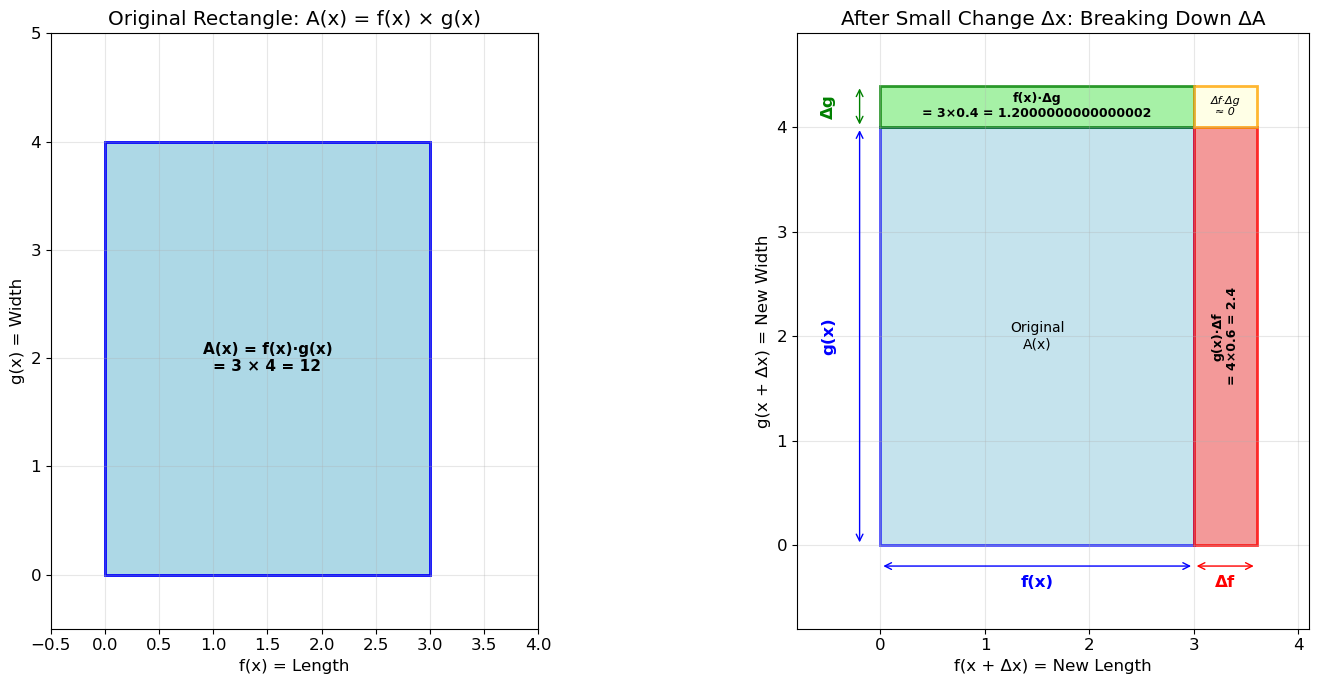

📊 AREA CHANGE BREAKDOWN:
Original Area A(x) = f(x) × g(x) = 3 × 4 = 12
New Area A(x+Δx) = 3.6 × 4.4 = 15.840000000000002
Total Change ΔA = 3.8400000000000016

Breaking down ΔA into components:
• f(x) × Δg = 3 × 0.4 = 1.2000000000000002 (green region)
• g(x) × Δf = 4 × 0.6 = 2.4 (red region)
• Δf × Δg = 0.6 × 0.4 = 0.24 (yellow corner - becomes negligible)
• Sum = 1.2000000000000002 + 2.4 + 0.24 = 3.84 ✓

🔑 KEY INSIGHT:
As Δx → 0, the yellow corner (Δf × Δg) shrinks fastest and can be ignored!
This leaves us with: ΔA ≈ f(x)×Δg + g(x)×Δf


In [7]:
# Visualize the geometric intuition behind the product rule

def create_product_rule_visualization():
    """Create a clear visualization showing how the product rule emerges from geometry"""
    
    # Example functions at a specific point
    x_val = 2
    f_x = 3  # f(x) = length
    g_x = 4  # g(x) = width
    
    # Small change
    delta_x = 0.5
    delta_f = 0.6  # change in f(x)
    delta_g = 0.4  # change in g(x)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    # Original rectangle
    ax1.add_patch(Rectangle((0, 0), f_x, g_x, facecolor='lightblue', 
                           edgecolor='blue', linewidth=2, label='Original Area A(x)'))
    ax1.text(f_x/2, g_x/2, f'A(x) = f(x)·g(x)\n= {f_x} × {g_x} = {f_x*g_x}', 
             ha='center', va='center', fontsize=11, weight='bold')
    ax1.set_xlim(-0.5, f_x + 1)
    ax1.set_ylim(-0.5, g_x + 1)
    ax1.set_xlabel('f(x) = Length')
    ax1.set_ylabel('g(x) = Width')
    ax1.set_title('Original Rectangle: A(x) = f(x) × g(x)')
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')
    
    # After the change
    new_f = f_x + delta_f
    new_g = g_x + delta_g
    
    # Original rectangle (same)
    ax2.add_patch(Rectangle((0, 0), f_x, g_x, facecolor='lightblue', 
                           edgecolor='blue', linewidth=2, alpha=0.7))
    ax2.text(f_x/2, g_x/2, 'Original\nA(x)', ha='center', va='center', fontsize=10)
    
    # New area due to change in g(x) only (horizontal strip)
    ax2.add_patch(Rectangle((0, g_x), f_x, delta_g, facecolor='lightgreen', 
                           edgecolor='green', linewidth=2, alpha=0.8))
    ax2.text(f_x/2, g_x + delta_g/2, f'f(x)·Δg\n= {f_x}×{delta_g} = {f_x*delta_g}', 
             ha='center', va='center', fontsize=9, weight='bold')
    
    # New area due to change in f(x) only (vertical strip)
    ax2.add_patch(Rectangle((f_x, 0), delta_f, g_x, facecolor='lightcoral', 
                           edgecolor='red', linewidth=2, alpha=0.8))
    ax2.text(f_x + delta_f/2, g_x/2, f'g(x)·Δf\n= {g_x}×{delta_f} = {g_x*delta_f}', 
             ha='center', va='center', fontsize=9, weight='bold', rotation=90)
    
    # New area due to both changes (small corner rectangle)
    ax2.add_patch(Rectangle((f_x, g_x), delta_f, delta_g, facecolor='lightyellow', 
                           edgecolor='orange', linewidth=2, alpha=0.8))
    ax2.text(f_x + delta_f/2, g_x + delta_g/2, f'Δf·Δg\n≈ 0', 
             ha='center', va='center', fontsize=8, style='italic')
    
    # Add dimension labels
    ax2.annotate('', xy=(0, -0.2), xytext=(f_x, -0.2), 
                arrowprops=dict(arrowstyle='<->', color='blue'))
    ax2.text(f_x/2, -0.4, 'f(x)', ha='center', color='blue', weight='bold')
    
    ax2.annotate('', xy=(new_f, -0.2), xytext=(f_x, -0.2), 
                arrowprops=dict(arrowstyle='<->', color='red'))
    ax2.text(f_x + delta_f/2, -0.4, 'Δf', ha='center', color='red', weight='bold')
    
    ax2.annotate('', xy=(-0.2, 0), xytext=(-0.2, g_x), 
                arrowprops=dict(arrowstyle='<->', color='blue'))
    ax2.text(-0.5, g_x/2, 'g(x)', ha='center', va='center', color='blue', weight='bold', rotation=90)
    
    ax2.annotate('', xy=(-0.2, new_g), xytext=(-0.2, g_x), 
                arrowprops=dict(arrowstyle='<->', color='green'))
    ax2.text(-0.5, g_x + delta_g/2, 'Δg', ha='center', va='center', color='green', weight='bold', rotation=90)
    
    ax2.set_xlim(-0.8, new_f + 0.5)
    ax2.set_ylim(-0.8, new_g + 0.5)
    ax2.set_xlabel('f(x + Δx) = New Length')
    ax2.set_ylabel('g(x + Δx) = New Width')
    ax2.set_title('After Small Change Δx: Breaking Down ΔA')
    ax2.grid(True, alpha=0.3)
    ax2.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()
    
    # Calculate and display the changes
    original_area = f_x * g_x
    new_area = new_f * new_g
    delta_a = new_area - original_area
    
    # Breaking down delta_a
    term1 = f_x * delta_g
    term2 = g_x * delta_f
    term3 = delta_f * delta_g
    
    print("📊 AREA CHANGE BREAKDOWN:")
    print("="*50)
    print(f"Original Area A(x) = f(x) × g(x) = {f_x} × {g_x} = {original_area}")
    print(f"New Area A(x+Δx) = {new_f} × {new_g} = {new_area}")
    print(f"Total Change ΔA = {delta_a}")
    print()
    print("Breaking down ΔA into components:")
    print(f"• f(x) × Δg = {f_x} × {delta_g} = {term1} (green region)")
    print(f"• g(x) × Δf = {g_x} × {delta_f} = {term2} (red region)")  
    print(f"• Δf × Δg = {delta_f} × {delta_g} = {term3} (yellow corner - becomes negligible)")
    print(f"• Sum = {term1} + {term2} + {term3} = {term1 + term2 + term3} ✓")
    print()
    print("🔑 KEY INSIGHT:")
    print("As Δx → 0, the yellow corner (Δf × Δg) shrinks fastest and can be ignored!")
    print("This leaves us with: ΔA ≈ f(x)×Δg + g(x)×Δf")

create_product_rule_visualization()

## Mathematical Derivation: From Geometry to Formula

Now let's translate our geometric insight into the precise mathematical formula. We'll use the formal definition of the derivative while keeping our geometric intuition in mind.

### Step 1: Set up the Problem

We want to find: $\frac{d}{dx}[f(x) \cdot g(x)]$

Starting with the definition of a derivative:
$$\frac{d}{dx}[f(x) \cdot g(x)] = \lim_{\Delta x \to 0} \frac{f(x + \Delta x) \cdot g(x + \Delta x) - f(x) \cdot g(x)}{\Delta x}$$

### Step 2: Express the Change in Area

From our rectangle analogy:
- **Original Area**: $A(x) = f(x) \cdot g(x)$
- **New Area**: $A(x + \Delta x) = f(x + \Delta x) \cdot g(x + \Delta x)$
- **Change in Area**: $\Delta A = A(x + \Delta x) - A(x)$

### Step 3: Break Down the Change

Using our geometric breakdown:
$$\Delta A = f(x) \cdot \Delta g + g(x) \cdot \Delta f + \Delta f \cdot \Delta g$$

Where:
- $\Delta f = f(x + \Delta x) - f(x)$
- $\Delta g = g(x + \Delta x) - g(x)$

### Step 4: Divide by $\Delta x$ and Take the Limit

$$\frac{\Delta A}{\Delta x} = \frac{f(x) \cdot \Delta g}{\Delta x} + \frac{g(x) \cdot \Delta f}{\Delta x} + \frac{\Delta f \cdot \Delta g}{\Delta x}$$

As $\Delta x \to 0$:
- $\frac{\Delta g}{\Delta x} \to g'(x)$ (definition of derivative)
- $\frac{\Delta f}{\Delta x} \to f'(x)$ (definition of derivative)  
- $\frac{\Delta f \cdot \Delta g}{\Delta x} \to 0$ (since $\Delta f \to 0$ as $\Delta x \to 0$)

### Step 5: The Product Rule Formula

$$\boxed{\frac{d}{dx}[f(x) \cdot g(x)] = f(x) \cdot g'(x) + g(x) \cdot f'(x)}$$

### Memory Aids

**"First times the derivative of the second, plus second times the derivative of the first"**

Or using the mnemonic: **"d(uv) = u dv + v du"**

## Interactive Examples: Applying the Product Rule

Let's work through several examples to build confidence with the product rule. We'll verify our analytical results using both symbolic computation and numerical methods.

In [8]:
# Interactive Product Rule Examples with Verification

def product_rule_example(f_expr, g_expr, f_name="f(x)", g_name="g(x)", example_num=1):
    """
    Demonstrate the product rule step-by-step with verification
    """
    x = symbols('x')
    
    print(f"📝 EXAMPLE {example_num}")
    print("="*50)
    print(f"Given: {f_name} = {f_expr}")
    print(f"       {g_name} = {g_expr}")
    print(f"Find: d/dx[{f_name} · {g_name}]")
    print()
    
    # Calculate derivatives
    f_prime = diff(f_expr, x)
    g_prime = diff(g_expr, x)
    product = f_expr * g_expr
    
    print("Step 1: Find the individual derivatives")
    print(f"f'(x) = d/dx[{f_expr}] = {f_prime}")
    print(f"g'(x) = d/dx[{g_expr}] = {g_prime}")
    print()
    
    print("Step 2: Apply the Product Rule")
    print("d/dx[f(x)·g(x)] = f(x)·g'(x) + g(x)·f'(x)")
    
    # Product rule calculation step by step
    term1 = f_expr * g_prime
    term2 = g_expr * f_prime
    product_rule_result = term1 + term2
    
    print(f"                 = ({f_expr})·({g_prime}) + ({g_expr})·({f_prime})")
    print(f"                 = {term1} + {term2}")
    print(f"                 = {simplify(product_rule_result)}")
    print()
    
    # Verification: direct differentiation
    direct_result = diff(product, x)
    simplified_direct = simplify(direct_result)
    simplified_product_rule = simplify(product_rule_result)
    
    print("✅ VERIFICATION:")
    print(f"Direct differentiation of ({f_expr})·({g_expr}) = {simplified_direct}")
    print(f"Product rule result = {simplified_product_rule}")
    print(f"Match: {simplified_direct == simplified_product_rule} ✓")
    print("\n" + "="*50 + "\n")

# Example 1: Polynomial × Polynomial
print("🎯 PRODUCT RULE EXAMPLES")
print("Let's work through several examples to master this technique!\n")

product_rule_example(x**2, x**3, "f(x)", "g(x)", 1)

# Example 2: Polynomial × Exponential  
product_rule_example(2*x + 1, sp.exp(x), "f(x) = 2x + 1", "g(x) = e^x", 2)

# Example 3: Trigonometric × Polynomial
product_rule_example(sp.sin(x), x**2, "f(x) = sin(x)", "g(x) = x²", 3)

🎯 PRODUCT RULE EXAMPLES
Let's work through several examples to master this technique!



NameError: name 'x' is not defined

## Visual Understanding: Comparing Functions and Their Derivatives

Let's visualize how the product rule works by plotting functions and their derivatives. This will help us see the relationship between the components and the final result.

🎨 VISUAL EXAMPLE: f(x) = x², g(x) = sin(x)


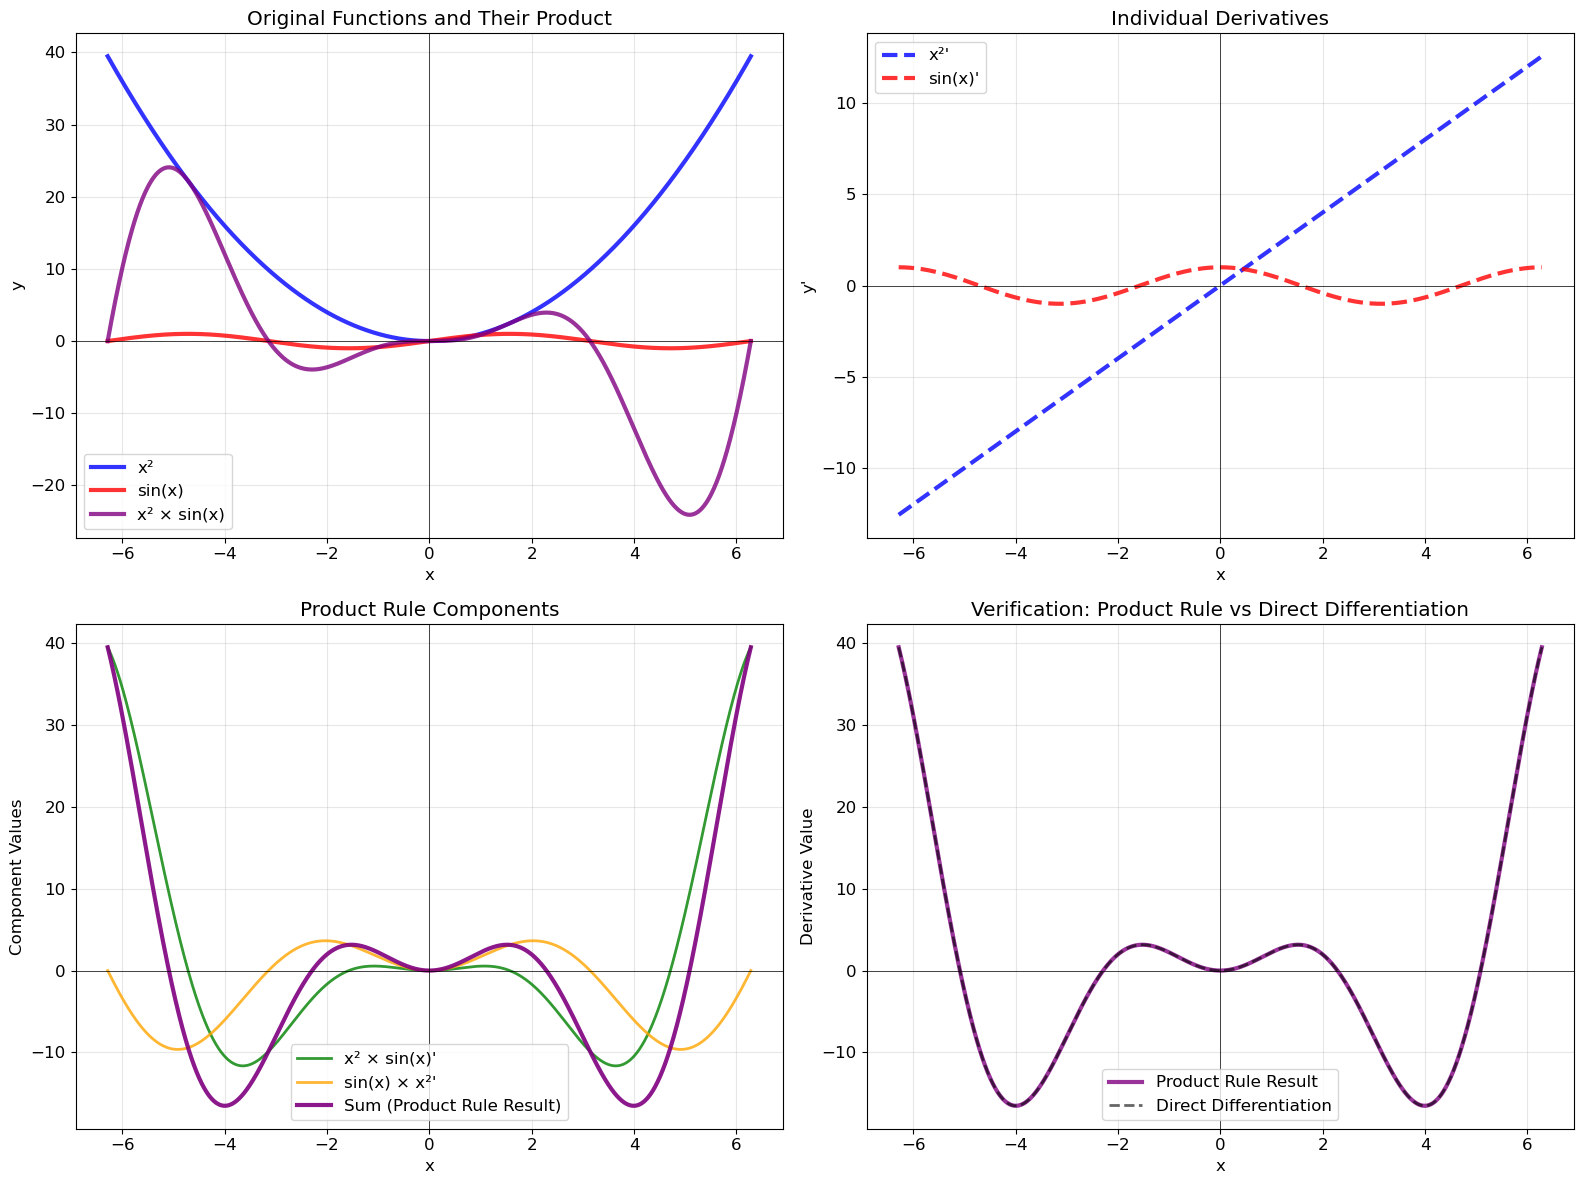

✅ Maximum difference between Product Rule and Direct Differentiation: 3.26e-07
(This should be very close to zero, confirming our product rule implementation)


In [9]:
# Visualize Product Rule in Action

def visualize_product_rule(f_func, g_func, f_name, g_name, x_range=(-3, 3)):
    """
    Create comprehensive visualization showing:
    1. Original functions f(x) and g(x)
    2. Their product f(x)·g(x)
    3. Individual derivatives f'(x) and g'(x)
    4. Product rule components
    5. Final derivative
    """
    
    x_vals = np.linspace(x_range[0], x_range[1], 1000)
    
    # Evaluate functions
    f_vals = f_func(x_vals)
    g_vals = g_func(x_vals)
    product_vals = f_vals * g_vals
    
    # Numerical derivatives (for verification)
    def numerical_derivative(func, x, h=1e-8):
        return (func(x + h) - func(x)) / h
    
    f_prime_vals = np.array([numerical_derivative(f_func, x) for x in x_vals])
    g_prime_vals = np.array([numerical_derivative(g_func, x) for x in x_vals])
    
    # Product rule components
    term1_vals = f_vals * g_prime_vals  # f(x) · g'(x)
    term2_vals = g_vals * f_prime_vals  # g(x) · f'(x)
    product_derivative_vals = term1_vals + term2_vals
    
    # Create subplot visualization
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Original Functions
    ax1.plot(x_vals, f_vals, 'b-', linewidth=3, label=f'{f_name}', alpha=0.8)
    ax1.plot(x_vals, g_vals, 'r-', linewidth=3, label=f'{g_name}', alpha=0.8)
    ax1.plot(x_vals, product_vals, 'purple', linewidth=3, label=f'{f_name} × {g_name}', alpha=0.8)
    ax1.set_title('Original Functions and Their Product')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='k', linewidth=0.5)
    ax1.axvline(x=0, color='k', linewidth=0.5)
    
    # Plot 2: Individual Derivatives
    ax2.plot(x_vals, f_prime_vals, 'b--', linewidth=3, label=f"{f_name}'", alpha=0.8)
    ax2.plot(x_vals, g_prime_vals, 'r--', linewidth=3, label=f"{g_name}'", alpha=0.8)
    ax2.set_title('Individual Derivatives')
    ax2.set_xlabel('x')
    ax2.set_ylabel("y'")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='k', linewidth=0.5)
    ax2.axvline(x=0, color='k', linewidth=0.5)
    
    # Plot 3: Product Rule Components
    ax3.plot(x_vals, term1_vals, 'green', linewidth=2, label=f'{f_name} × {g_name}\'', alpha=0.8)
    ax3.plot(x_vals, term2_vals, 'orange', linewidth=2, label=f'{g_name} × {f_name}\'', alpha=0.8)
    ax3.plot(x_vals, product_derivative_vals, 'purple', linewidth=3, 
             label='Sum (Product Rule Result)', alpha=0.9)
    ax3.set_title('Product Rule Components')
    ax3.set_xlabel('x')
    ax3.set_ylabel('Component Values')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.axhline(y=0, color='k', linewidth=0.5)
    ax3.axvline(x=0, color='k', linewidth=0.5)
    
    # Plot 4: Final Comparison
    # Direct numerical derivative of the product
    product_direct_derivative = np.array([numerical_derivative(lambda x: f_func(x) * g_func(x), x) 
                                        for x in x_vals])
    
    ax4.plot(x_vals, product_derivative_vals, 'purple', linewidth=3, 
             label='Product Rule Result', alpha=0.8)
    ax4.plot(x_vals, product_direct_derivative, 'k--', linewidth=2, 
             label='Direct Differentiation', alpha=0.6)
    ax4.set_title('Verification: Product Rule vs Direct Differentiation')
    ax4.set_xlabel('x')
    ax4.set_ylabel('Derivative Value')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    ax4.axhline(y=0, color='k', linewidth=0.5)
    ax4.axvline(x=0, color='k', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()
    
    # Calculate maximum difference for verification
    max_diff = np.max(np.abs(product_derivative_vals - product_direct_derivative))
    print(f"✅ Maximum difference between Product Rule and Direct Differentiation: {max_diff:.2e}")
    print("(This should be very close to zero, confirming our product rule implementation)")

# Example: f(x) = x², g(x) = sin(x)
print("🎨 VISUAL EXAMPLE: f(x) = x², g(x) = sin(x)")
print("="*60)

def f_example(x):
    return x**2

def g_example(x):
    return np.sin(x)

visualize_product_rule(f_example, g_example, "x²", "sin(x)", x_range=(-2*np.pi, 2*np.pi))

## Common Mistakes and How to Avoid Them

Understanding what **NOT** to do is just as important as knowing the correct method. Let's examine common mistakes students make with the product rule.

In [10]:
# Common Mistakes with the Product Rule

def demonstrate_mistakes():
    """Show common mistakes and correct approaches"""
    
    x = symbols('x')
    
    # Example function: f(x) = x² · e^x
    f = x**2
    g = sp.exp(x)
    product = f * g
    
    print("🚨 COMMON MISTAKES WITH THE PRODUCT RULE")
    print("="*60)
    print(f"Let's differentiate: f(x) = x² · e^x")
    print()
    
    # Mistake 1: Just multiplying the derivatives
    print("❌ MISTAKE #1: Just multiply the derivatives")
    print("   Wrong thinking: d/dx[f·g] = f'·g'")
    
    f_prime = diff(f, x)
    g_prime = diff(g, x)
    wrong_result = f_prime * g_prime
    
    print(f"   f'(x) = {f_prime}")
    print(f"   g'(x) = {g_prime}")
    print(f"   Wrong answer: f'·g' = ({f_prime})·({g_prime}) = {wrong_result}")
    print()
    
    # Correct approach
    print("✅ CORRECT: Apply the Product Rule")
    print("   Right formula: d/dx[f·g] = f·g' + g·f'")
    
    term1 = f * g_prime  # f·g'
    term2 = g * f_prime  # g·f'
    correct_result = term1 + term2
    
    print(f"   f·g' = ({f})·({g_prime}) = {term1}")
    print(f"   g·f' = ({g})·({f_prime}) = {term2}")
    print(f"   Correct answer: {term1} + {term2} = {simplify(correct_result)}")
    print()
    
    # Verification
    direct_result = diff(product, x)
    print("🔍 VERIFICATION:")
    print(f"   Direct differentiation: {simplify(direct_result)}")
    print(f"   Product rule result: {simplify(correct_result)}")
    print(f"   Match: {simplify(direct_result) == simplify(correct_result)} ✓")
    print()
    
    # Show the difference numerically
    x_test = 1
    wrong_value = float(wrong_result.subs(x, x_test))
    correct_value = float(correct_result.subs(x, x_test))
    
    print(f"📊 NUMERICAL COMPARISON at x = {x_test}:")
    print(f"   Wrong method gives: {wrong_value:.4f}")
    print(f"   Correct method gives: {correct_value:.4f}")
    print(f"   Difference: {abs(correct_value - wrong_value):.4f}")
    print("   This shows why the product rule is essential!")
    print()
    
    # Mistake 2: Forgetting one term
    print("❌ MISTAKE #2: Forgetting one of the terms")
    print("   Sometimes students remember only f·g' or only g·f'")
    
    only_first_term = term1
    only_second_term = term2
    
    print(f"   Only f·g': {simplify(only_first_term)}")
    print(f"   Only g·f': {simplify(only_second_term)}")
    print(f"   Complete answer: {simplify(correct_result)}")
    print()
    
    print("💡 MEMORY AID:")
    print("   'First times derivative of second, PLUS second times derivative of first'")
    print("   Always remember BOTH terms and the PLUS sign!")

demonstrate_mistakes()

print("\n" + "="*60)
print("🎯 PRACTICE TIPS:")
print("1. Always write down f(x) and g(x) clearly")
print("2. Find f'(x) and g'(x) separately") 
print("3. Apply formula: d/dx[f·g] = f·g' + g·f'")
print("4. Simplify your final answer")
print("5. Verify with direct differentiation when possible")

🚨 COMMON MISTAKES WITH THE PRODUCT RULE
Let's differentiate: f(x) = x² · e^x

❌ MISTAKE #1: Just multiply the derivatives
   Wrong thinking: d/dx[f·g] = f'·g'
   f'(x) = 2*x
   g'(x) = exp(x)
   Wrong answer: f'·g' = (2*x)·(exp(x)) = 2*x*exp(x)

✅ CORRECT: Apply the Product Rule
   Right formula: d/dx[f·g] = f·g' + g·f'
   f·g' = (x**2)·(exp(x)) = x**2*exp(x)
   g·f' = (exp(x))·(2*x) = 2*x*exp(x)
   Correct answer: x**2*exp(x) + 2*x*exp(x) = x*(x + 2)*exp(x)

🔍 VERIFICATION:
   Direct differentiation: x*(x + 2)*exp(x)
   Product rule result: x*(x + 2)*exp(x)
   Match: True ✓

📊 NUMERICAL COMPARISON at x = 1:
   Wrong method gives: 5.4366
   Correct method gives: 8.1548
   Difference: 2.7183
   This shows why the product rule is essential!

❌ MISTAKE #2: Forgetting one of the terms
   Sometimes students remember only f·g' or only g·f'
   Only f·g': x**2*exp(x)
   Only g·f': 2*x*exp(x)
   Complete answer: x*(x + 2)*exp(x)

💡 MEMORY AID:
   'First times derivative of second, PLUS second t

## Practice Problems: Test Your Understanding

Now it's time to apply what you've learned! Try solving these problems yourself before looking at the solutions.

In [ ]:
# Practice Problems with Step-by-Step Solutions

def practice_problem(problem_num, f_expr, g_expr, description):
    """Generate and solve a practice problem"""
    
    x = symbols('x')
    
    print(f"📝 PROBLEM {problem_num}")
    print("="*40)
    print(f"{description}")
    print(f"Find: d/dx[({f_expr}) · ({g_expr})]")
    print()
    print("Try solving this yourself first, then check the solution below!")
    print()
    
    # Give some thinking space
    print("🤔 Your work:")
    print("f(x) = ")
    print("g(x) = ")
    print("f'(x) = ")
    print("g'(x) = ")
    print("Product rule: f·g' + g·f' = ")
    print()
    print("👀 SOLUTION:")
    print("-" * 20)
    
    # Solution
    f_prime = diff(f_expr, x)
    g_prime = diff(g_expr, x)
    
    print(f"f(x) = {f_expr}")
    print(f"g(x) = {g_expr}")
    print(f"f'(x) = {f_prime}")
    print(f"g'(x) = {g_prime}")
    print()
    
    term1 = f_expr * g_prime
    term2 = g_expr * f_prime
    result = simplify(term1 + term2)
    
    print("Applying the product rule:")
    print(f"d/dx[f·g] = f·g' + g·f'")
    print(f"         = ({f_expr})·({g_prime}) + ({g_expr})·({f_prime})")
    print(f"         = {term1} + {term2}")
    print(f"         = {result}")
    
    # Verification
    direct = diff(f_expr * g_expr, x)
    print(f"\n✅ Verification: Direct differentiation gives {simplify(direct)}")
    print(f"Match: {simplify(result) == simplify(direct)} ✓")
    print("\n" + "="*40 + "\n")

print("🎯 PRACTICE PROBLEMS")
print("Test your understanding with these carefully selected problems!\n")

# Problem 1: Basic polynomial product
practice_problem(1, x**3, 2*x + 5, 
                "Differentiate the product of two polynomials")

# Problem 2: Polynomial and exponential
practice_problem(2, 3*x**2 - 1, sp.exp(2*x), 
                "Combine polynomial with exponential function")

# Problem 3: Trigonometric and polynomial
practice_problem(3, sp.cos(x), x**2 + 1, 
                "Mix trigonometric and polynomial functions")

# Problem 4: More complex example
practice_problem(4, x*sp.sin(x), sp.exp(x), 
                "A product that itself contains a product")

print("🌟 BONUS CHALLENGE:")
print("Can you use the product rule twice to differentiate (x²)(sin(x))(eˣ)?")
print("Hint: Think of it as [x²·sin(x)]·eˣ or x²·[sin(x)·eˣ]")

## Real-World Applications: Why the Product Rule Matters

The product rule isn't just an abstract mathematical concept—it appears frequently in real-world scenarios where multiple changing quantities interact. Let's explore some practical applications.

In [ ]:
# Real-World Applications of the Product Rule

def business_revenue_example():
    """
    Application 1: Business Revenue Analysis
    Revenue = Price × Quantity, both changing over time
    """
    print("💼 APPLICATION 1: BUSINESS REVENUE")
    print("="*50)
    print("A company's revenue R(t) = P(t) × Q(t) where:")
    print("• P(t) = price per unit (changes over time)")
    print("• Q(t) = quantity sold (changes over time)")
    print("• t = time (months)")
    print()
    
    t = symbols('t')
    
    # Define price and quantity functions
    P = 50 - 0.5*t  # Price decreases over time (market competition)
    Q = 100 + 2*t   # Quantity increases over time (market growth)
    
    print(f"Given:")
    print(f"P(t) = {P} (price decreases due to competition)")
    print(f"Q(t) = {Q} (quantity increases due to market growth)")
    print()
    
    # Revenue function
    R = P * Q
    print(f"Revenue: R(t) = P(t) × Q(t) = ({P}) × ({Q})")
    print(f"         R(t) = {expand(R)}")
    print()
    
    # Rate of change of revenue (using product rule)
    P_prime = diff(P, t)
    Q_prime = diff(Q, t)
    R_prime_product_rule = P * Q_prime + Q * P_prime
    
    print("To find how fast revenue changes, we use the product rule:")
    print("dR/dt = P(t)·dQ/dt + Q(t)·dP/dt")
    print(f"      = ({P})·({Q_prime}) + ({Q})·({P_prime})")
    print(f"      = {simplify(R_prime_product_rule)}")
    print()
    
    # Interpretation at specific time
    t_val = 6  # 6 months
    P_val = float(P.subs(t, t_val))
    Q_val = float(Q.subs(t, t_val))
    R_val = float(R.subs(t, t_val))
    R_prime_val = float(R_prime_product_rule.subs(t, t_val))
    
    print(f"📊 ANALYSIS at t = {t_val} months:")
    print(f"Price: ${P_val:.2f} per unit")
    print(f"Quantity: {Q_val} units")
    print(f"Revenue: ${R_val:.2f}")
    print(f"Rate of revenue change: ${R_prime_val:.2f} per month")
    
    if R_prime_val > 0:
        print("💹 Revenue is INCREASING (good news!)")
    else:
        print("📉 Revenue is DECREASING (need strategy change!)")
    print()

def physics_power_example():
    """
    Application 2: Physics - Power in Electrical Circuits
    Power = Voltage × Current, both varying with time
    """
    print("⚡ APPLICATION 2: ELECTRICAL POWER")
    print("="*50)
    print("In an AC circuit, both voltage and current vary with time:")
    print("• V(t) = voltage across a component")
    print("• I(t) = current through the component")
    print("• P(t) = V(t) × I(t) = instantaneous power")
    print()
    
    t = symbols('t')
    
    # AC voltage and current (sinusoidal)
    V = 120 * sp.cos(60*t)  # 120V amplitude, 60 Hz frequency  
    I = 5 * sp.sin(60*t)    # 5A amplitude, same frequency
    
    print(f"Given:")
    print(f"V(t) = {V} volts")
    print(f"I(t) = {I} amperes")
    print()
    
    # Power function
    P = V * I
    print(f"Power: P(t) = V(t) × I(t)")
    print(f"       P(t) = ({V}) × ({I})")
    print()
    
    # Rate of change of power
    V_prime = diff(V, t)
    I_prime = diff(I, t)
    P_prime = V * I_prime + I * V_prime
    
    print("Rate of power change (using product rule):")
    print("dP/dt = V(t)·dI/dt + I(t)·dV/dt")
    print(f"      = ({V})·({I_prime}) + ({I})·({V_prime})")
    print()
    
    print("🔬 PHYSICAL INTERPRETATION:")
    print("• First term V·dI/dt: power change due to current variation")
    print("• Second term I·dV/dt: power change due to voltage variation")
    print("• Both contribute to the total rate of power change")
    print()

def population_growth_example():
    """
    Application 3: Biology - Population Dynamics
    Total biomass = Population size × Average individual mass
    """
    print("🧬 APPLICATION 3: POPULATION BIOMASS")
    print("="*50)
    print("In ecology, total biomass B(t) = N(t) × m(t) where:")
    print("• N(t) = number of individuals in population")
    print("• m(t) = average mass per individual")
    print("• Both change over time due to growth and environmental factors")
    print()
    
    t = symbols('t')
    
    # Population grows exponentially, but individual mass decreases due to resource competition
    N = 1000 * sp.exp(0.1*t)    # Population grows exponentially
    m = 2 / (1 + 0.05*t)        # Average mass decreases due to competition
    
    print(f"Given:")
    print(f"N(t) = {N} (population size)")
    print(f"m(t) = {m} (average individual mass in kg)")
    print()
    
    # Total biomass
    B = N * m
    print(f"Total Biomass: B(t) = N(t) × m(t)")
    print()
    
    # Rate of biomass change
    N_prime = diff(N, t)
    m_prime = diff(m, t)
    B_prime = N * m_prime + m * N_prime
    
    print("Rate of biomass change (using product rule):")
    print("dB/dt = N(t)·dm/dt + m(t)·dN/dt")
    print()
    print("🌱 ECOLOGICAL INTERPRETATION:")
    print("• N(t)·dm/dt: biomass change due to individual mass changes")
    print("• m(t)·dN/dt: biomass change due to population size changes")  
    print("• The interplay determines whether total biomass increases or decreases")
    print()

# Run all applications
business_revenue_example()
physics_power_example() 
population_growth_example()

print("🌟 KEY INSIGHT:")
print("In all these applications, we have two quantities that change simultaneously,")
print("and their PRODUCT is what we're interested in tracking. The product rule")
print("helps us understand how the rate of change of the product depends on")
print("the rates of change of both individual quantities!")

## Summary: Mastering the Product Rule

Congratulations! You've now explored the product rule from multiple angles. Let's consolidate what we've learned.

### 🧠 **Key Conceptual Understanding**

1. **Geometric Intuition**: The product rule emerges naturally from thinking about how the area of a rectangle changes when both dimensions change simultaneously.

2. **Mathematical Formula**: 
   $$\boxed{\frac{d}{dx}[f(x) \cdot g(x)] = f(x) \cdot g'(x) + g(x) \cdot f'(x)}$$

3. **Memory Device**: "First times the derivative of the second, **plus** second times the derivative of the first"

### ⚠️ **What NOT to Do**
- ❌ Don't just multiply the derivatives: $\frac{d}{dx}[f \cdot g] \neq f' \cdot g'$
- ❌ Don't forget the second term: it's not just $f \cdot g'$
- ❌ Don't forget the addition sign between terms

### 🎯 **When to Use the Product Rule**
Use the product rule whenever you have:
- Two functions multiplied together: $h(x) = f(x) \cdot g(x)$
- Products that can't be simplified first
- Real-world situations involving interacting quantities

### 🔗 **Connection to Other Rules**
- **Sum Rule**: For $f(x) + g(x)$, derivatives add simply
- **Product Rule**: For $f(x) \cdot g(x)$, we need this special formula
- **Chain Rule**: For composite functions $f(g(x))$ (coming next!)
- **Quotient Rule**: For $\frac{f(x)}{g(x)}$ (can be derived from product rule!)

### 🌍 **Real-World Impact**
The product rule appears everywhere:
- **Business**: Revenue = Price × Quantity (both changing)
- **Physics**: Power = Voltage × Current (both variable)
- **Biology**: Biomass = Population × Individual Mass
- **Economics**: Cost = Unit Price × Volume
- **Engineering**: Force = Mass × Acceleration (in variable mass systems)

### 📈 **Your Mathematical Toolkit**
You now have these powerful differentiation tools:
1. ✅ **Power Rule**: $\frac{d}{dx}[x^n] = nx^{n-1}$
2. ✅ **Sum Rule**: $\frac{d}{dx}[f + g] = f' + g'$
3. ✅ **Product Rule**: $\frac{d}{dx}[f \cdot g] = f \cdot g' + g \cdot f'$
4. 🔜 **Chain Rule**: Coming next!
5. 🔜 **Quotient Rule**: Can be derived from product rule

### 🎓 **Next Steps**
- Practice applying the product rule to various function types
- Look for opportunities to use it in combination with other rules
- Prepare for the **Chain Rule** - the next essential technique
- Start recognizing when products appear in real-world problems

---

**Remember**: Mathematics is not about memorizing formulas—it's about understanding patterns and relationships. The product rule reveals how rates of change interact when quantities are multiplied together. This insight will serve you well throughout calculus and beyond!